In [107]:
# Adjust import path
import sys
sys.path.append("../ODEs")
sys.path.append("../")

In [108]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

import config_lotka_volterra as config
import step1_generate_data as step1
import step3_estimate as step3
import step4_plot as step4
import numpy as np
import random

seed = 21092023  # Or any integer you prefer

np.random.seed(seed)
random.seed(seed)
%load_ext autoreload
%autoreload 2
import importlib
import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Create Data

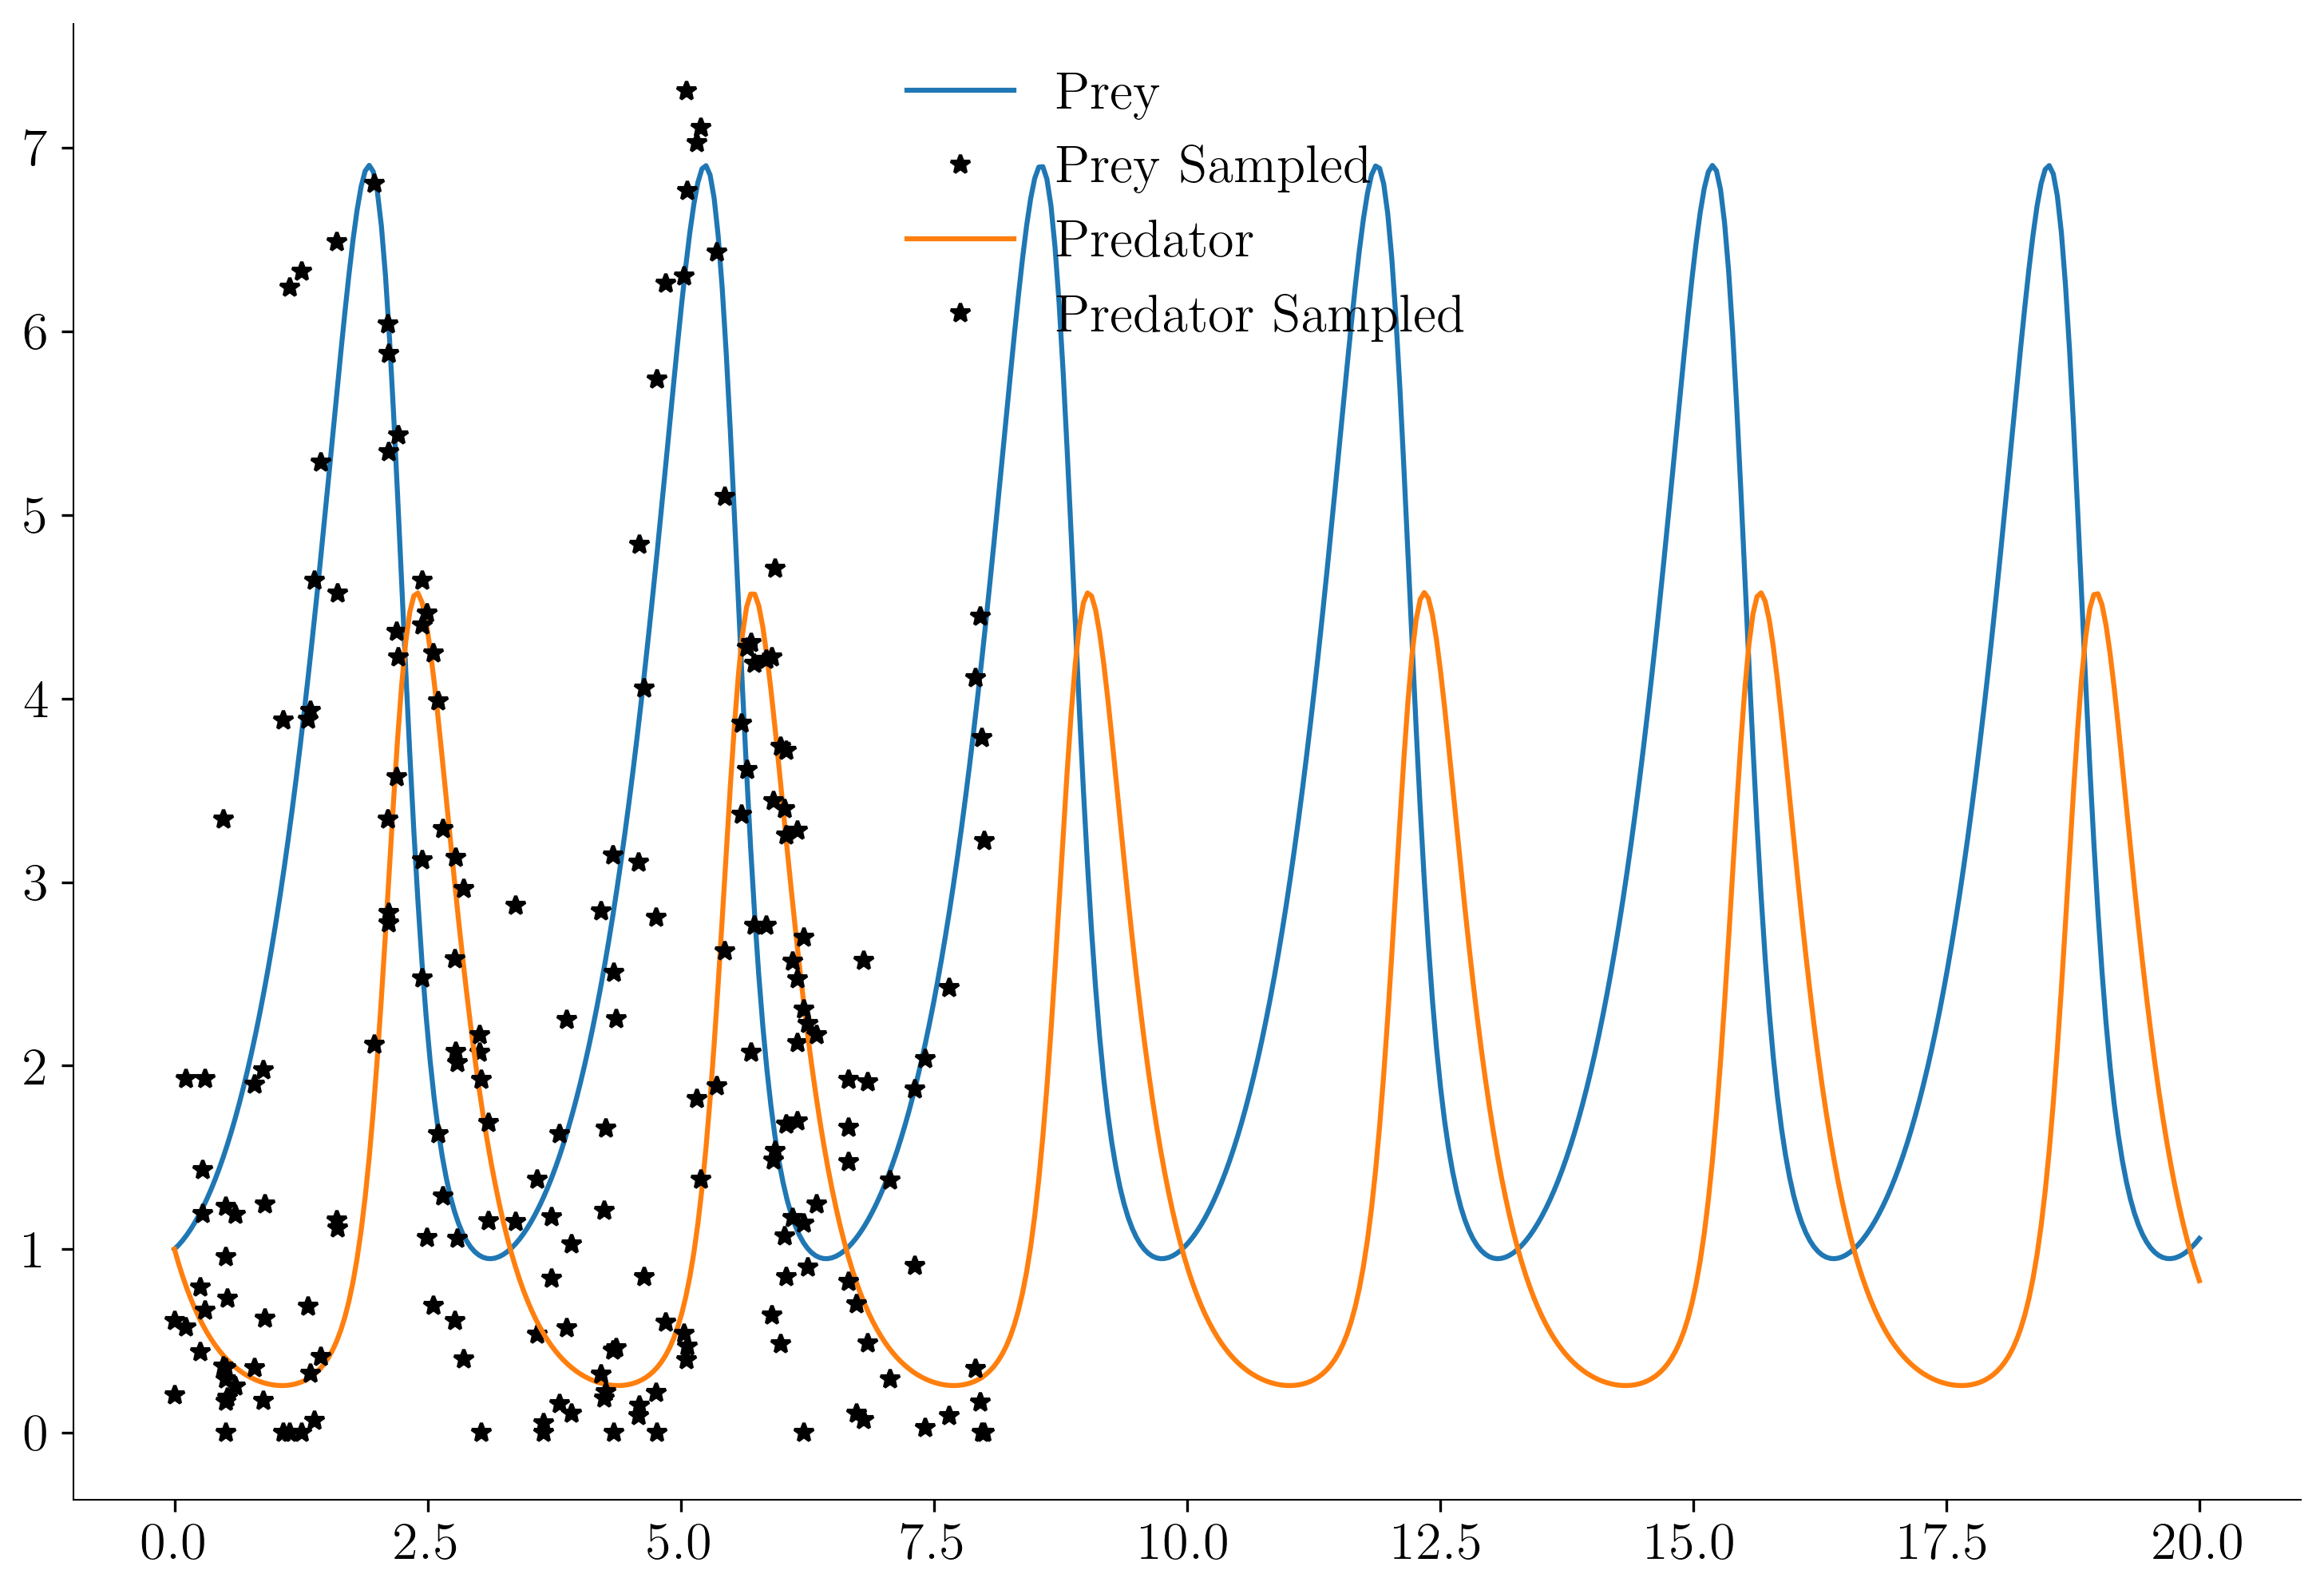

In [109]:
training_span = (0,8)
num_samples = 100
noiselevel = .3
num_regression_points = 300
# Step 1: Generate data ---------------------------------------------------
config.alpha, config.beta, config.gamma, config.delta = 1.5, 1, 3, 1
sampler = step1.TrajectorySampler(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    synced=True,
    integersonly=False,
    config=config,
)

(
    truthmodel,
    time_domain_prediction,
    true_states,
    time_domains_sampled,
    snapshots_sampled,
) = sampler.sample()
true_parameters = np.copy(truthmodel.parameters)

num_vars = len(true_states)
for i in range(num_vars):
    plt.plot(time_domain_prediction, true_states[i], label='Prey' if i == 0 else 'Predator')
    plt.plot(time_domains_sampled[i], snapshots_sampled[i], 'k*', label='Prey Sampled' if i == 0 else 'Predator Sampled')
plt.legend()
plt.show()

### Train GPS

(100,) (2, 100) (200,)
Iter   0, neg-log-lik = 1225.4800
Iter  10, neg-log-lik = 965.0194
Iter  20, neg-log-lik = 813.2949
Iter  30, neg-log-lik = 709.7356
Iter  40, neg-log-lik = 627.8219
Iter  49, neg-log-lik = 565.1305
Final parameters:
  lengthscale: 0.712390
  variance: 1.405128
  noise: 0.015694


/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_71242/3501152198.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


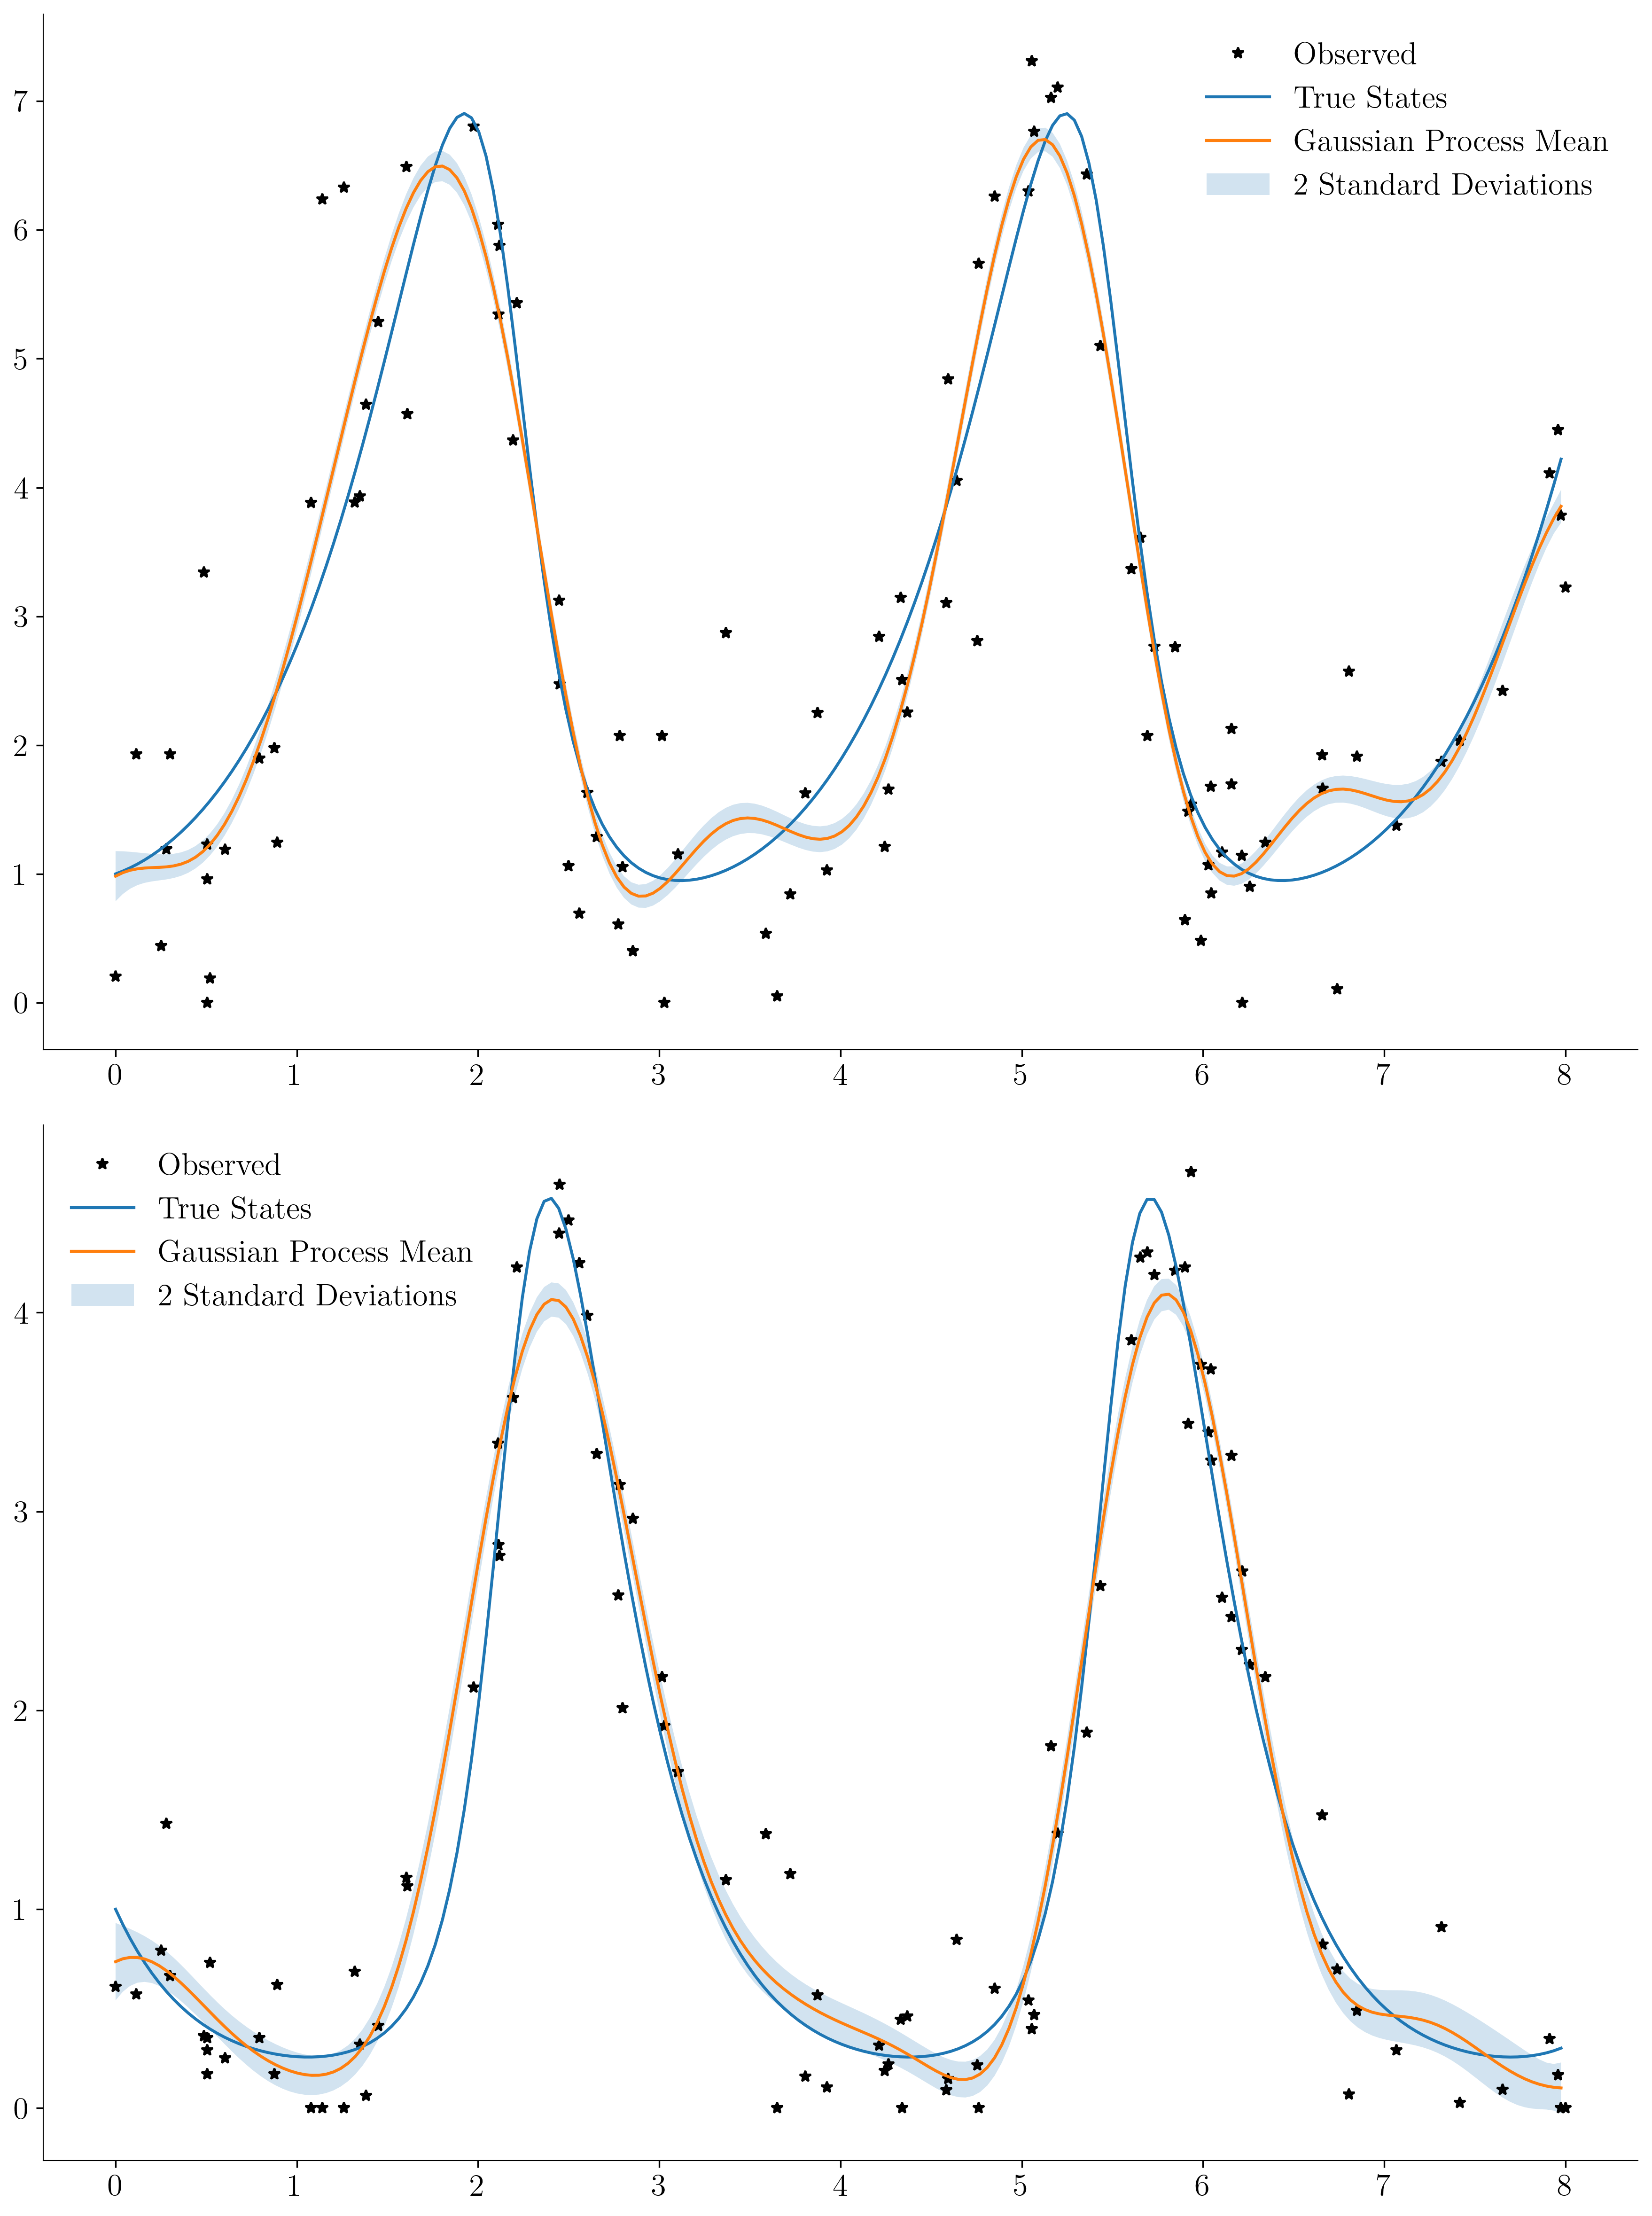

In [110]:
from jax_gp import GaussianProcess
import jax.numpy as jnp


# Define the data
time = time_domains_sampled[0] # Take the first becauase when using sync they are all the same
y = snapshots_sampled
dims, snaps = y.shape
time_domain_train_window = time_domain_prediction[time_domain_prediction <= time.max()]
true_states_train_window = true_states[:,:time_domain_train_window.size]
print(time.shape, y.shape, time_domain_train_window.shape)


# Fit the gp
gp = GaussianProcess(learning_rate=0.01)
losses = gp.fit(time, y, n_iter=50)


# Plot the predictions
fig, ax = plt.subplots(2,1, figsize = (12,16))
for i in range(dims):
    mu, std = gp.predict(X_train=time, X_test=time_domain_train_window, y_train=snapshots_sampled[i])
    ax[i].plot(time, y[i].T, 'k*', label = 'Observed')
    ax[i].plot(time_domain_train_window, true_states_train_window[i].T, label='True States')
    ax[i].plot(time_domain_train_window, mu, label='Gaussian Process Mean')
    ax[i].fill_between(time_domain_train_window, mu - 2*std, mu + 2*std, label='2 Standard Deviations', alpha = .2)
    ax[i].legend() 
fig.tight_layout()
fig.show()

In [111]:
import numpyro
import numpyro.distributions as dist
from jax_gp import get_dash_c_phi
import jax
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO
from numpyro.optim import Adam

def jax_f(x, theta):
        """
        \dot{x_0} = x_0 * (theta_0 - theta_1*x_1)
        \dot{x_1} = -x_1 * (theta_2 - theta_3*x_0)
        will return derivatives in a vector
        """
        firstODE = x[0]*(theta[0] - theta[1]*x[1])
        secondODE = -x[1]*(theta[2] - theta[3]*x[0])
        return jnp.array([firstODE, secondODE])

def model(y, time, gp, gamma=1e-3):
    T, D = y.shape                    # y is (T,2)

    theta = numpyro.sample('theta',
               dist.LogNormal(0., 1.).expand([4]).to_event(1))

    C     = gp.get_kernel_matrix(time)          # (T,T)
    C_d   = gp.get_kernel_derivative_dt1(time)
    C_dd  = gp.get_kernel_double_derivative(time)
    Cp = jnp.block([[C, C_d], [C_d.T, C_dd]])   # (2T,2T) one state
    Dash = get_dash_c_phi(gp.params, time) @ jnp.linalg.solve(C, jnp.eye(T))
    A    = gp.get_As(time)[0]

    with numpyro.plate('state', D):             # ← plate over predator / prey
        x = numpyro.sample('x', dist.MultivariateNormal(
                                loc=jnp.zeros(T), covariance_matrix=C))
        numpyro.sample('obs',
            dist.MultivariateNormal(x, gp.hyperparameters['noise']*jnp.eye(T)),
            obs=y.T)

        # center each state‐trajectory along the time axis
        x_centered = x - x.mean(axis=1, keepdims=True)   # shape (D, T)

        # apply Dash to each of the D centered vectors:
        mu_f = jnp.einsum('ij,kj->ki', Dash, x_centered)

        cov_f = A + gamma*jnp.eye(T)
        f_val = jax_f(x, theta)                     # your f returns (T,) in the plate
        numpyro.sample('grad_match',
            dist.MultivariateNormal(mu_f, cov_f),
            obs=f_val)

nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=1000)
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key, y.T, time, gp)

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_71242/2282020923.py:10: SyntaxWarning: invalid escape sequence '\d'
  """
sample: 100%|██████████| 2000/2000 [00:08<00:00, 229.00it/s, 63 steps of size 3.26e-02. acc. prob=0.92] 


In [112]:
# Analyze samples
samples = mcmc.get_samples()
samples.keys()

dict_keys(['theta', 'x'])

In [113]:
mean_params = samples['theta'].mean(axis=0)
param_samples = samples['theta']
trajectories = []
for i in range(60):
    theta = param_samples[i]
    config.alpha, config.beta, config.delta, config.gamma = theta[0], theta[1], theta[3], theta[2]
    sampler = step1.TrajectorySampler(
        training_span=training_span,
        num_samples=num_samples,
        noiselevel=noiselevel,
        num_regression_points=num_regression_points,
        synced=True,
        integersonly=False,
        config=config,
    )

    (
        truthmodel,
        time_domain_prediction,
        true_states_not,
        time_domains_sampled,
        snapshots_sampled,
    ) = sampler.sample()
    trajectories.append(true_states_not)

# Get mean traj
newParams = mean_params
config.alpha, config.beta, config.delta, config.gamma = newParams[0], newParams[1], newParams[3], newParams[2]
sampler = step1.TrajectorySampler(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    synced=True,
    integersonly=False,
    config=config,
)

(
    truthmodel,
    time_domain_prediction,
    true_states_not,
    time_domains_sampled,
    snapshots_sampled,
) = sampler.sample()
time = time_domain_prediction
mean_traj = true_states_not

/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_71242/1165943668.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


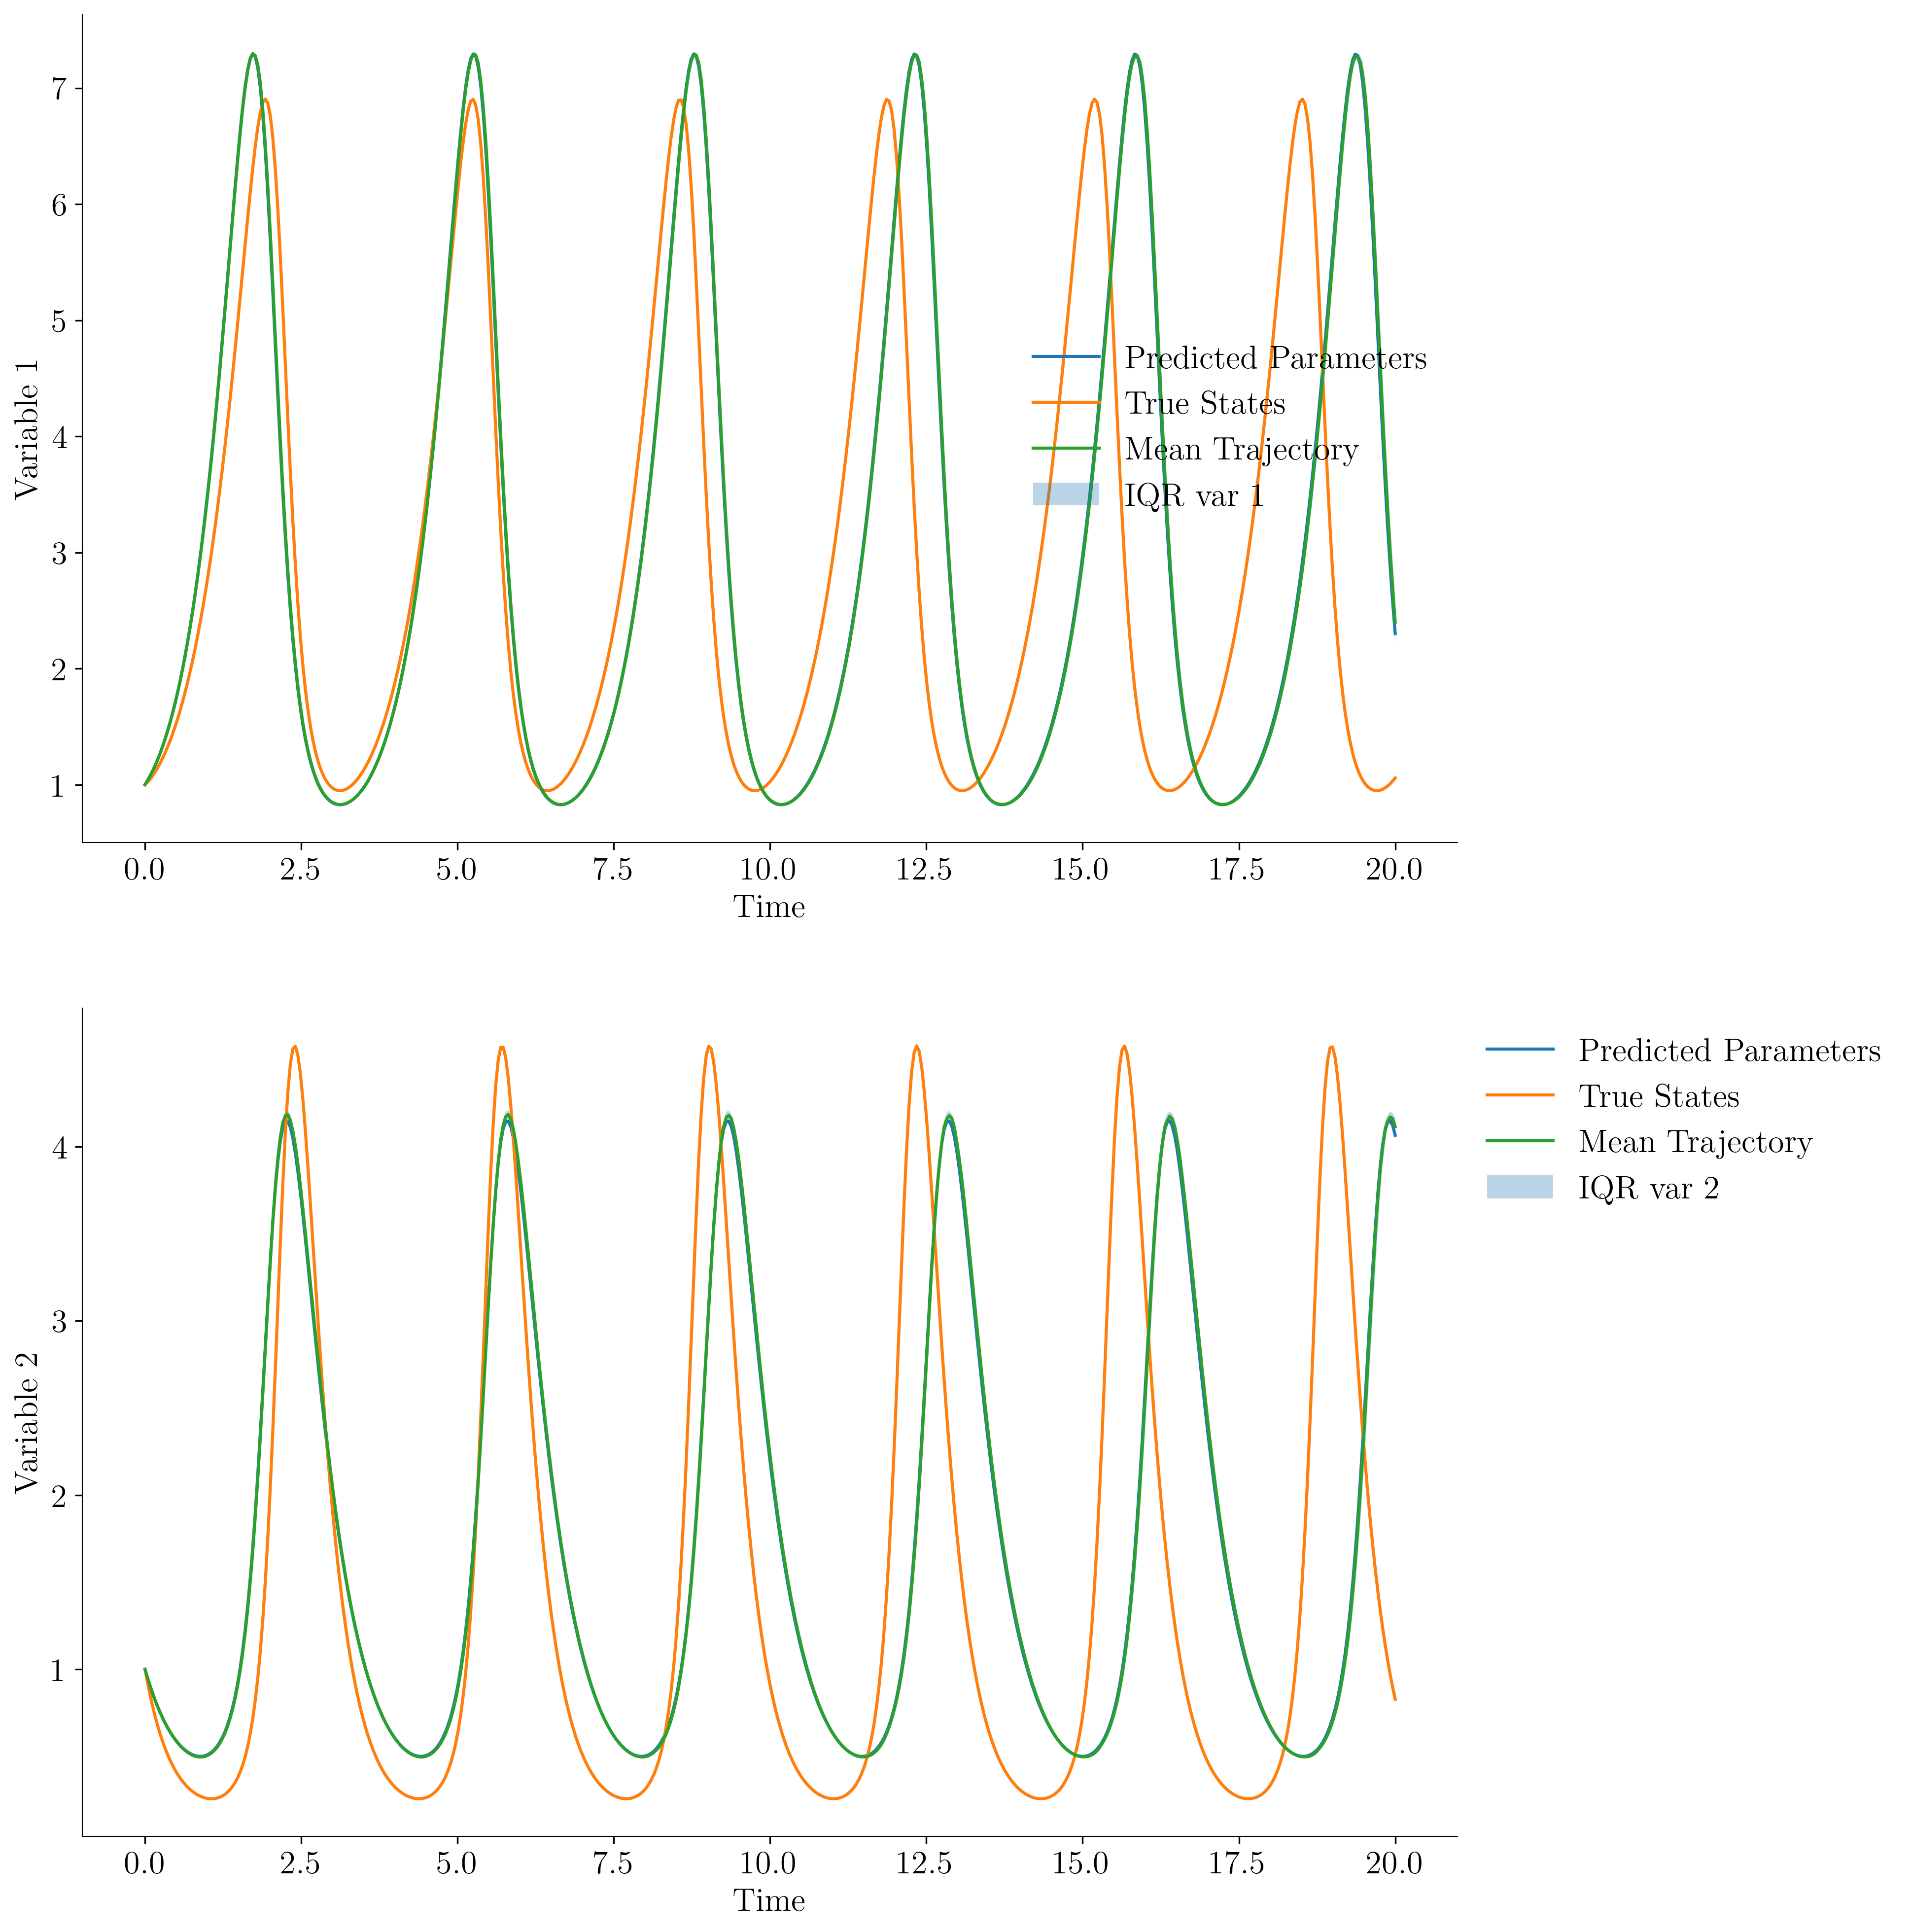

In [114]:
# Compute interquartile ranges
q1 = np.percentile(trajectories, 25, axis=0)
q3 = np.percentile(trajectories, 75, axis=0)
mean_of_traj = np.median(trajectories, axis=0)

# Plot variable 1
fig, ax = plt.subplots(2,1, figsize=(12,16))
ax[0].plot(time, mean_traj[0], label='Predicted Parameters')
ax[0].plot(time, true_states[0], label='True States')
ax[0].plot(time, mean_of_traj[0], label='Mean Trajectory')
ax[0].fill_between(time, q1[0], q3[0], alpha=0.3, label='IQR var 1')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Variable 1')
ax[0].legend()


# Plot variable 2
ax[1].plot(time, mean_traj[1], label='Predicted Parameters')
ax[1].plot(time, true_states[1], label='True States')
ax[1].plot(time, mean_of_traj[1], label='Mean Trajectory')
ax[1].fill_between(time, q1[1], q3[1], alpha=0.3, label='IQR var 2')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Variable 2')
ax[1].legend(bbox_to_anchor=(1, 1))

fig.show()